---
title: "Sovereign Default and Bank Sheet Fragility"
---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime as dt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path01 = '/content/drive/MyDrive/AD561/Assignments/Assignment 3/sovereign_risk_dataset.csv'
sovereign_risk= pd.read_csv(file_path01)

file_path02 = '/content/drive/MyDrive/AD561/Assignments/Assignment 3/bank_fragility_dataset.csv'
bank_fragility= pd.read_csv(file_path02)

# Part 0

No, this does not mean that it is safe over long periods of time. This is because, although we assume each year's probability is independent and the low probability remains consistent year-to-year, there is still a changing risk. This is because the years compound on each other, meaning they do not maintain the same low probabilities over an extended period of time due to the risks that occur from changing fiscal and political environments. This risk compounds mathematically, despite the probability remaining constant.

# Part 1 - Sovereign Risk Analysis

## Step 1 - Load and Inspect

In [4]:
sovereign_risk

,Country,Yield_i,RiskFree_i_star,Recovery_RR
0,Greece,0.090,0.030,0.35
1,Italy,0.060,0.030,0.45
2,Argentina,0.140,0.040,0.30
3,Spain,0.050,0.030,0.50
4,Turkey,0.110,0.040,0.40
5,Brazil,0.100,0.035,0.45
6,Portugal,0.055,0.030,0.50
7,Mexico,0.085,0.035,0.40


Country: The name of the country being used in this analysis

Yield_i: Sovereign Bond Yield, the annual return that investors demand to hold a country's sovereign bond

RiskFree_i_star: Risk-free Rate, theoretical return on an investment with zero default risk

Recovery_RR: The Recovery Rate, the fraction of the bonds face value that the investors expect to recover in the event of a default


## Step 2 - Compute Implied Default Probability

In [5]:
def compute_pd(yield_i, riskfree_i_star, recovery_rr):
    """
    Calculates the implied probability of default (PD).

    Parameters:
        yield_i:         Sovereign bond yield (i)
        riskfree_i_star: Risk-free rate (i*)
        recovery_rr:     Recovery rate (RR)

    Returns:
        Implied probability of default
    """
    return (1 - (1 + riskfree_i_star) / (1 + yield_i)) / (1 - recovery_rr)

sovereign_risk['PD'] = sovereign_risk.apply(
    lambda row: compute_pd(
        yield_i         = row['Yield_i'],
        riskfree_i_star = row['RiskFree_i_star'],
        recovery_rr     = row['Recovery_RR']
    ), axis=1
)

sovereign_risk

,Country,Yield_i,RiskFree_i_star,Recovery_RR,PD
0,Greece,0.090,0.030,0.35,0.084686
1,Italy,0.060,0.030,0.45,0.051458
2,Argentina,0.140,0.040,0.30,0.125313
3,Spain,0.050,0.030,0.50,0.038095
4,Turkey,0.110,0.040,0.40,0.105105
5,Brazil,0.100,0.035,0.45,0.107438
6,Portugal,0.055,0.030,0.50,0.047393
7,Mexico,0.085,0.035,0.40,0.076805


## Step 3 - Exploratory Data Analysis

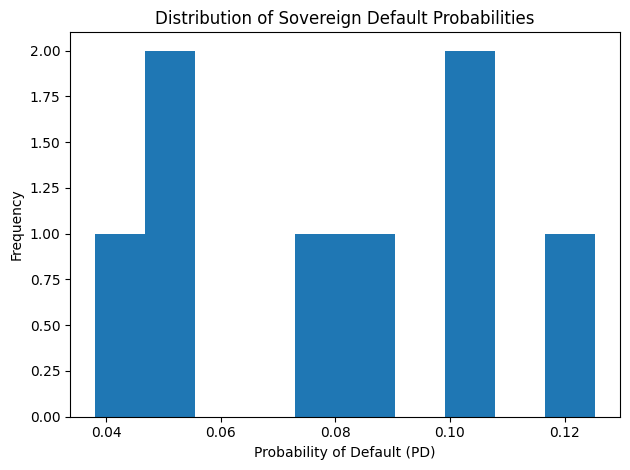

In [6]:
plt.hist(sovereign_risk['PD'])
plt.xlabel('Probability of Default (PD)')
plt.ylabel('Frequency')
plt.title('Distribution of Sovereign Default Probabilities')
plt.tight_layout()
plt.show()

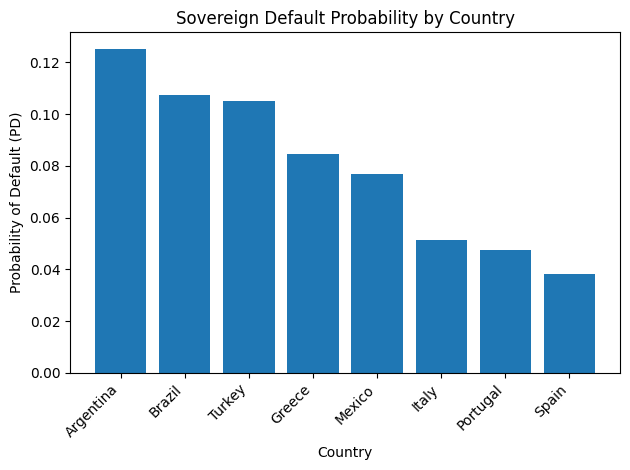

In [7]:
sorted_df = sovereign_risk.sort_values('PD', ascending=False)
plt.bar(sorted_df['Country'], sorted_df['PD'])
plt.xlabel('Country')
plt.ylabel('Probability of Default (PD)')
plt.title('Sovereign Default Probability by Country')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
sovereign_risk['PD'].describe()

,PD
count,8.000000
mean,0.079537
std,0.031849
min,0.038095
25%,0.050442
50%,0.080745
75%,0.105688
max,0.125313


## Step 4 - Interpretation

  The most risky country here is Argentina as they have the highest default probability at 12.5%. This is based on their input values into the default probability calcualtion of that included a yield of 14%, risk free rate of 4% and recovery rate of 30%. I would say that there is a wide spread of default probabilites, with a range between 3.8% (Spain) and 12.5% (Argentina). While the sample size is small, the median value is 8.07% suggesting that there is some significant spread between the lowest, highest and middle values. However, it is important to note that we would be able to gain a better understanding of the spread with a larger sample size. More samples would help us understand if this is a normal distrbution for default probabilies, or if they tend to skew to the right. Yield is a great indicator of the default probability, as the countries with a higher Yield generally have a higher default probability, but we cannot fully answer the default probability without knowing the recovery rate as it acts as a leverage multiplier on the default probability.

# Part 1B - Interactive Sovereign Risk Explorer

In [9]:
import ipywidgets as widgets
from IPython.display import display

In [10]:
import ipywidgets as widgets
from IPython.display import display

def compute_pd(yield_i, riskfree_i_star, recovery_rr):
    return (1 - (1 + riskfree_i_star) / (1 + yield_i)) / (1 - recovery_rr)

slider_style = {'description_width': '150px'}
slider_layout = widgets.Layout(width='600px')

yield_slider = widgets.FloatSlider(
    value=0.08, min=0.03, max=0.20, step=0.01,
    description='Yield (i):',
    style=slider_style, layout=slider_layout
)

riskfree_slider = widgets.FloatSlider(
    value=0.03, min=0.01, max=0.08, step=0.01,
    description='Risk-Free (i*):',
    style=slider_style, layout=slider_layout
)

recovery_slider = widgets.FloatSlider(
    value=0.40, min=0.20, max=0.70, step=0.01,
    description='Recovery (RR):',
    style=slider_style, layout=slider_layout
)

output = widgets.Output(layout=widgets.Layout(margin='20px 0px'))

def update(change=None):
    output.clear_output()

    y = yield_slider.value
    rf = riskfree_slider.value
    rr = recovery_slider.value

    pd_value = compute_pd(y, rf, rr)
    spread = y - rf
    lgd = 1 - rr

    with output:
        display(widgets.HTML(f"""
        <div style="font-size:18px; font-family:monospace; padding:20px; background:#f7f7f7; border-radius:10px; width:560px;">
            <div style="font-size:22px; font-weight:bold; margin-bottom:15px;">📥 Selected Input Values</div>
            <div style="margin:8px 0;">Sovereign Yield (i): <b>{y:.2%}</b></div>
            <div style="margin:8px 0;">Risk-Free Rate (i*): <b>{rf:.2%}</b></div>
            <div style="margin:8px 0;">Recovery Rate (RR): <b>{rr:.2%}</b></div>

            <hr style="margin:15px 0;">

            <div style="font-size:22px; font-weight:bold; margin-bottom:15px;">📤 Computed Outputs</div>
            <div style="margin:8px 0;">Yield Spread (i - i*): <b>{spread:.2%}</b></div>
            <div style="margin:8px 0;">Loss Given Default (1 - RR): <b>{lgd:.2%}</b></div>
            <div style="margin:8px 0; font-size:26px; color:#c0392b;">
                Implied PD: <b>{pd_value:.4%}</b>
            </div>
        </div>
        """))

yield_slider.observe(update, names='value')
riskfree_slider.observe(update, names='value')
recovery_slider.observe(update, names='value')

update()

display(widgets.VBox([
    widgets.HTML("<h2 style='font-size:26px;'>🌍 Sovereign Default Probability Calculator</h2>"),
    yield_slider,
    riskfree_slider,
    recovery_slider,
    output
], layout=widgets.Layout(padding='20px')))

Scenario 1: The Safe Haven
- Yield: 3%
- Risk-Free Rate: 1%
- Recovery Rate: 70%
Implied PD: 6.4725%

Scenario 2: The Emerging Market
- Yield: 10%
- Risk-Free Rate: 4%
- Recovery Rate: 45%
Implied PD: 9.91745

Scenario 3: The Distressed Sovereign
- Yield: 20%
- Risk-Free Rate: 8%
- Recovery Rate: 70%
Implied PD: 33.3333%


The three different scenarios that I modelled illustrate how sovereign defauly probabilities respond to yield, risk-free rates and recovery rates. In Scenario 1, "The Safe Haven", we see the lowest yield and risk-free rate, with the highest recovery. The implied default probability is the lowest of the three I compared, reflecting a country that has strong creditor protections and modest borrowing costs. In Scenario 2, "The Emerging Market", shows a moderate yield spread with middling recovery rates that produce a defauly probability of just under 10%. This risk reflects that of a developing economym a higher risk than one that is established but far from distress. The recovery rate is doing meaninguful work here to stabilize this. Finally, in Scenario 3, "The Distressed Sovereign", a high yield signals that markets are pricing in serious default, and despite a higher recovery rate, the defauly probability still reaches 33.33%. The wide spread between the the yield and risk-free rate removes from the recovery completely, reflecting a country in or near a debt crisis. A notable observation here is that although Scenario 1 & 3 share an identical recovery rate of 70%, their implied default probabilities differ by almost 27%, isolating the yield spread as a dominant driver of the default probabiliy with higher risk levels.


The sovereign yield has the strongest effect on the default probability. As previously mentioned, when going from Scenario 1 where the yield is 3% and the risk-free rate is 1%, to Scenario 3m where the yield is 20% and the risk free rate is 8%, we saw nearly a 27% increase from 6.47% to 33.33%. The recovery rate acts as a leverage multiplier, however its moderating power weakens as the sovereign yield rises further from the risk-free rate. It is clear that the relationship between these variables is non-linear. From Scenario 1 and Scenario 2, the sovereign yield rose from 3% to 10%, yet default probability only increased from 6.47% to 9.92%, a small, modest rise. Comparatively, from Scenario 2 and Scenario 3, the sovereign yield rose from 10% to 20%, yet the the default probability rose from 9.92% to 33.33%, a far larger jump. This confirms that the relationship is non-linear, and intensifies at higher yield levels. The most surprising find here is that although Scenario 1 and 3 share the same recovery rate, there default probabilites differed by 26.86% points. It challenged my natural intuition, as when the sovereign yield is sufficiently elevated, the recovery rate loses its moderating influence almost entirely.

# Part 2 - Shock Scenario

## Step 1 - Apply a Shock

In [11]:
sovereign_risk_shock = sovereign_risk.copy()
sovereign_risk_shock['Yield_i_shock'] = sovereign_risk_shock['Yield_i'] + 0.04

## Step 2 - Recompute PD

In [12]:
sovereign_risk_shock['SHOCK'] = sovereign_risk.apply(
    lambda row: compute_pd(
        yield_i         = row['Yield_i'] + 0.04,
        riskfree_i_star = row['RiskFree_i_star'],
        recovery_rr     = row['Recovery_RR']
    ), axis=1
)

In [13]:
sovereign_risk_shock

,Country,Yield_i,RiskFree_i_star,Recovery_RR,PD,Yield_i_shock,SHOCK
0,Greece,0.090,0.030,0.35,0.084686,0.130,0.136147
1,Italy,0.060,0.030,0.45,0.051458,0.100,0.115702
2,Argentina,0.140,0.040,0.30,0.125313,0.180,0.169492
3,Spain,0.050,0.030,0.50,0.038095,0.090,0.110092
4,Turkey,0.110,0.040,0.40,0.105105,0.150,0.159420
5,Brazil,0.100,0.035,0.45,0.107438,0.140,0.167464
6,Portugal,0.055,0.030,0.50,0.047393,0.095,0.118721
7,Mexico,0.085,0.035,0.40,0.076805,0.125,0.133333


## Step 3 - Visualization

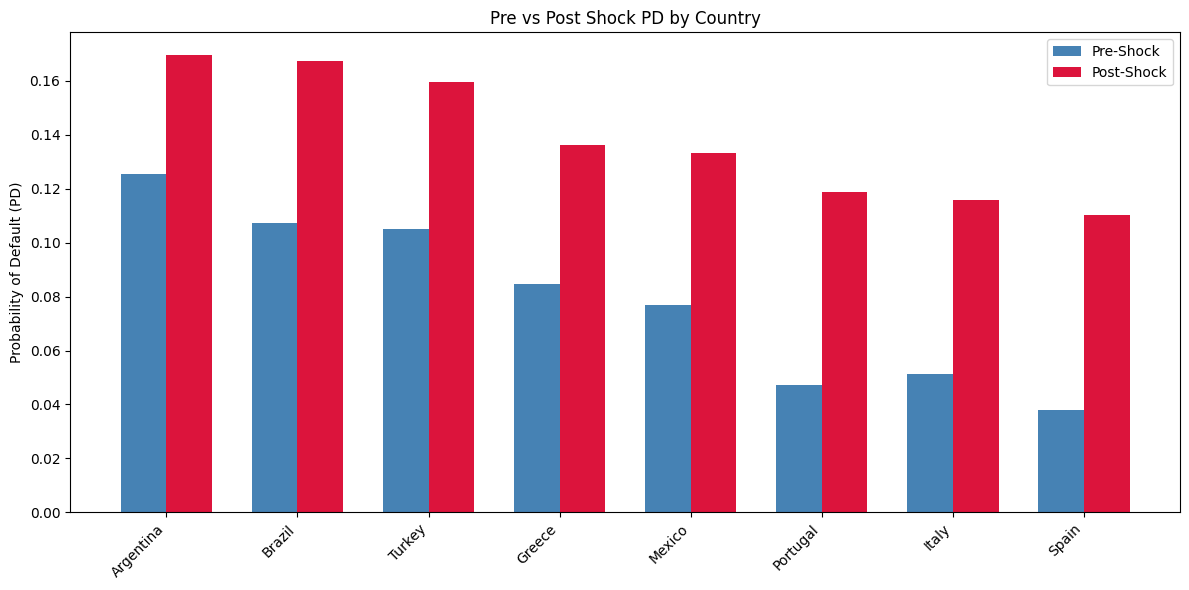

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))

sovereign_risk_shock_sorted = sovereign_risk_shock.sort_values('SHOCK', ascending=False)

x     = np.arange(len(sovereign_risk_shock_sorted['Country']))
width = 0.35

ax.bar(x - width/2, sovereign_risk_shock_sorted['PD'],    width, label='Pre-Shock',  color='steelblue')
ax.bar(x + width/2, sovereign_risk_shock_sorted['SHOCK'], width, label='Post-Shock', color='crimson')

ax.set_xticks(x)
ax.set_xticklabels(sovereign_risk_shock_sorted['Country'], rotation=45, ha='right')
ax.set_ylabel('Probability of Default (PD)')
ax.set_title('Pre vs Post Shock PD by Country')
ax.legend()
plt.tight_layout()
plt.show()

## Step 4 - Interpretation

In [15]:
sovereign_risk_shock['PD_Shock_Difference'] = sovereign_risk_shock['SHOCK'] - sovereign_risk_shock['PD']
display(sovereign_risk_shock[['Country', 'PD', 'SHOCK', 'PD_Shock_Difference']].sort_values(by='PD_Shock_Difference', ascending=False))

,Country,PD,SHOCK,PD_Shock_Difference
3,Spain,0.038095,0.110092,0.071997
6,Portugal,0.047393,0.118721,0.071328
1,Italy,0.051458,0.115702,0.064245
5,Brazil,0.107438,0.167464,0.060026
7,Mexico,0.076805,0.133333,0.056528
4,Turkey,0.105105,0.159420,0.054315
0,Greece,0.084686,0.136147,0.051461
2,Argentina,0.125313,0.169492,0.044178


In [16]:
print('Ranking by PD (largest to smallest):')
display(sovereign_risk_shock[['Country', 'PD']].sort_values(by='PD', ascending=False))

print('\nRanking by SHOCK (largest to smallest):')
display(sovereign_risk_shock[['Country', 'SHOCK']].sort_values(by='SHOCK', ascending=False))

Ranking by PD (largest to smallest):


,Country,PD
2,Argentina,0.125313
5,Brazil,0.107438
4,Turkey,0.105105
0,Greece,0.084686
7,Mexico,0.076805
1,Italy,0.051458
6,Portugal,0.047393
3,Spain,0.038095



Ranking by SHOCK (largest to smallest):


,Country,SHOCK
2,Argentina,0.169492
5,Brazil,0.167464
4,Turkey,0.159420
0,Greece,0.136147
7,Mexico,0.133333
6,Portugal,0.118721
1,Italy,0.115702
3,Spain,0.110092


The countries that changed the most were Spain and Portugal, which showed default probability increases of 7.20% and 7.13% points respectively. However, it is valuable to note that even the country with the smallest change, Argentina, still increased by 4.42% points, showing that the shock had a significant impact across the entire system. In terms of rankings, the order stayed mostly the same, with the only change being between Portugal and Italy, who switched places from 3rd lowest and 2nd lowest respectively. This swap occurred due to their differing recovery rates - Portugal's recovery rate of 0.50 amplifies the impact of the yield shock more than Italy's rate of 0.45, causing Portugal's default probability to increase by more and overtake Italy post-shock. As a result of the shock, the system became meaningfully more fragile, with all default probabilities increasing substantially. Spain, which initially had the smallest default probability, saw an increase from 3.81% to 11.01%, nearly tripling its pre-shock value. At the top, Argentina saw an increase of 4.42% points, demonstrating that even countries already carrying higher default probabilities were not immune to the shock. The main takeaway is that no country was safe from the yield shock, and it produced significant increases across the entire sovereign risk environment.

# Part 3 - Portfolio Risk

## Step 1 - Compute System-Level Risk

In [17]:
import numpy as np

def prob_at_least_one_default(pd_values):
    """
    Calculates the probability that at least one country defaults.
    Formula: P(at least one) = 1 - ∏(1 - PD_i)

    Parameters:
        pd_values: array-like of individual country PD values (post-shock)

    Returns:
        Probability that at least one country defaults
    """
    survival_probs = [1 - pd for pd in pd_values]
    prob_none_default = np.prod(survival_probs)
    return 1 - prob_none_default

# Extract post-shock PD values
post_shock_pds = sovereign_risk_shock['SHOCK'].values

# Calculate
result = prob_at_least_one_default(post_shock_pds)

print(f"Post-Shock PD Values:")
for country, pd in zip(sovereign_risk_shock['Country'], post_shock_pds):
    print(f"  {country}: {pd:.4%}")

print(f"\nP(at least one default) = {result:.4%}")

Post-Shock PD Values:
  Greece: 13.6147%
  Italy: 11.5702%
  Argentina: 16.9492%
  Spain: 11.0092%
  Turkey: 15.9420%
  Brazil: 16.7464%
  Portugal: 11.8721%
  Mexico: 13.3333%

P(at least one default) = 69.8231%


## Step 2 - Sensitvity

In [18]:
# Remove the riskiest country based on the highest post-shock PD
riskiest_country = sovereign_risk_shock.loc[sovereign_risk_shock['SHOCK'].idxmax(), 'Country']
riskiest_pd = sovereign_risk_shock['SHOCK'].max()

sovereign_risk_shock_filtered = sovereign_risk_shock[
    sovereign_risk_shock['Country'] != riskiest_country
]

# Recompute
post_shock_pds_filtered = sovereign_risk_shock_filtered['SHOCK'].values
result_filtered = prob_at_least_one_default(post_shock_pds_filtered)

print(f"Riskiest country removed: {riskiest_country} ({riskiest_pd:.4%})")
print("\nPost-Shock PD Values (Riskiest Country Removed):")
for country, pd in zip(sovereign_risk_shock_filtered['Country'], post_shock_pds_filtered):
    print(f"  {country}: {pd:.4%}")

print(f"\nP(at least one default) = {result_filtered:.4%}")
print(f"Previous result (all 8): {result:.4%}")
print(f"Reduction:               {result - result_filtered:.4%}")

Riskiest country removed: Argentina (16.9492%)

Post-Shock PD Values (Riskiest Country Removed):
  Greece: 13.6147%
  Italy: 11.5702%
  Spain: 11.0092%
  Turkey: 15.9420%
  Brazil: 16.7464%
  Portugal: 11.8721%
  Mexico: 13.3333%

P(at least one default) = 63.6645%
Previous result (all 8): 69.8231%
Reduction:               6.1586%


## Step 3 - Interpretation

 The combined probability is so high because of how the formula is designed to accumulate indiviudal risks across all the countries. Even though no singular country has a default probability above 16.95%, the probability that all eight survive simultaneously requirs every country to avoid default at the same time. The joint probability multiples the survival rate of all of them together, which compounds down quickly. The result is that only a 30.18% chance of them all surviving at the same time, leaving a 69.82% probability that at least one falls. With eight moderately risky sovereings, the system-wide risk is unavoidable. Removing Argentina, the riskiest country, only reduced the joint probability by 6.16%, reducing the likelihood of at least one default from 69.82% to 63.66%. This is meaningful, but not suprising as Argentina carried the largest individual risk. This example demonstrates that once a portfolio contains many moderate-risk entities, the systemic risk becomes distributed across the entire group rather than concentrated in any single country. This is why removing the riskiest country does is less impactful than intuition may suggest. Diversification does not enirely eliminate the risk in this context, and actually works against the investor. In portfolios, we look to diversify to spread the risk exposure, but in holding more sovereigns, the risk of one defaulting increases. Adding more countries actually increases the systemic risk, meaning the only way to get genuine protection is by seeking countries with substaintially lower default probabilities, not by holding more.

# Part 4 - Bank Fragility

## Step 1 - Load and Inspect

In [19]:
bank_fragility

,Bank,Assets,Liabilities,Bond_Portfolio,Uninsured_Deposits
0,Bank_A,100,92,40,60
1,Bank_B,120,108,50,70
2,Bank_C,80,70,25,40
3,Bank_D,150,135,70,90
4,Bank_E,90,82,30,55


## Step 2 - Compute Key Metrics

In [20]:
bank_fragility['Equity'] = bank_fragility['Assets'] - bank_fragility['Liabilities']
bank_fragility['Equity_Ratio'] = bank_fragility['Equity'] / bank_fragility['Assets']
bank_fragility

,Bank,Assets,Liabilities,Bond_Portfolio,Uninsured_Deposits,Equity,Equity_Ratio
0,Bank_A,100,92,40,60,8,0.080000
1,Bank_B,120,108,50,70,12,0.100000
2,Bank_C,80,70,25,40,10,0.125000
3,Bank_D,150,135,70,90,15,0.100000
4,Bank_E,90,82,30,55,8,0.088889


## Step 3 - Exploratory Data Analysis

In [21]:
bank_fragility['Equity_Ratio'].describe()

,Equity_Ratio
count,5.000000
mean,0.098778
std,0.016889
min,0.080000
25%,0.088889
50%,0.100000
75%,0.100000
max,0.125000


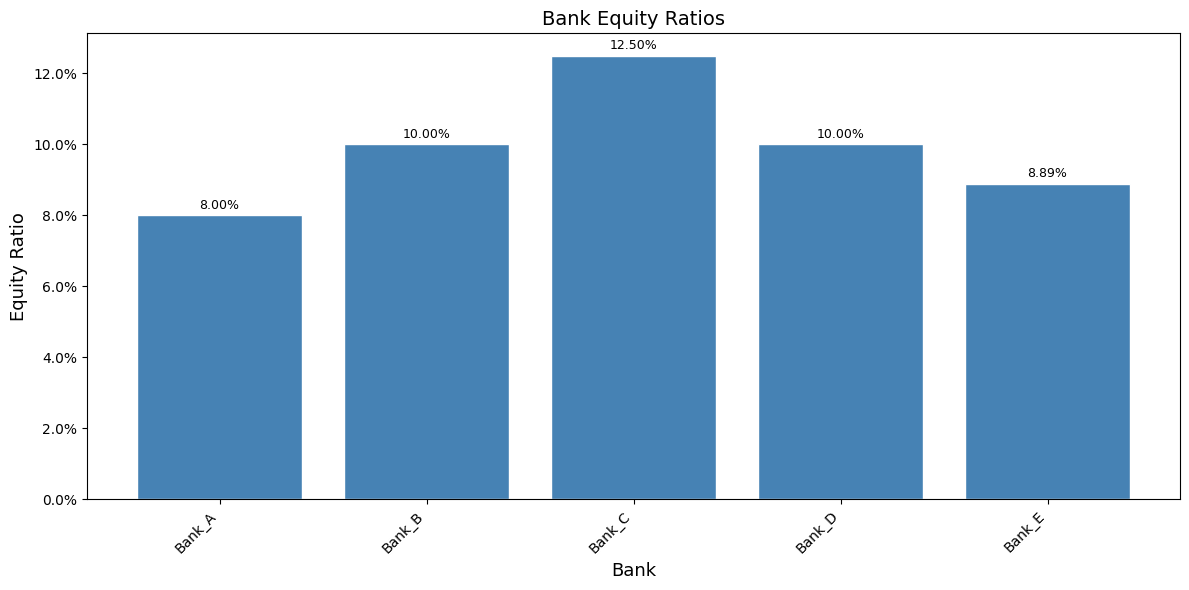

In [22]:
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.bar(bank_fragility['Bank'], bank_fragility['Equity_Ratio'], color='steelblue', edgecolor='white')

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{bar.get_height():.2%}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Bank', fontsize=13)
ax.set_ylabel('Equity Ratio', fontsize=13)
ax.set_title('Bank Equity Ratios', fontsize=14)
plt.xticks(rotation=45, ha='right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.1%}'))

plt.tight_layout()
plt.show()

The equity ratios range between 8% - 12.5%, with a mean of 9.8% and a standard deviation of 1.69%. This shows the banks are clustered closely togther, with limited capital buffers. There is not major skew or pattern in the distribution between each of the banks. One thing that is worth noting is the difference between the strongest and weakest institutions is only 4.5%, showing how a moderate shock applied unevenly across the system may push many of the banks into insolvency.

## Step 4 - Apply Your Shock

For the deposit withdrawal shock, I have chosen a withdrawal rate of 15%. This is because it reflects a moderate, but realistic stress scenario, where a meaningful portion of uninsured depositers decide to withdraw their funds simultaneously, reflecting an early bank run. Uninsured deposits are chosen as the shock variables as they represent the most volatile portion of a bank's funding, as depositers who are above the FDIC insurance threshold have the most incentive to withdraw quickly in times of uncertainty.

In [23]:
bank_fragility_shock = bank_fragility.copy()
deposit_reduction = bank_fragility_shock['Uninsured_Deposits'] * 0.15
bank_fragility_shock['Uninsured_Deposits_shock'] = bank_fragility_shock['Uninsured_Deposits'] - deposit_reduction
bank_fragility_shock['Assets_shock'] = bank_fragility_shock['Assets'] - deposit_reduction

bank_fragility_shock

,Bank,Assets,Liabilities,Bond_Portfolio,Uninsured_Deposits,Equity,Equity_Ratio,Uninsured_Deposits_shock,Assets_shock
0,Bank_A,100,92,40,60,8,0.080000,51.00,91.00
1,Bank_B,120,108,50,70,12,0.100000,59.50,109.50
2,Bank_C,80,70,25,40,10,0.125000,34.00,74.00
3,Bank_D,150,135,70,90,15,0.100000,76.50,136.50
4,Bank_E,90,82,30,55,8,0.088889,46.75,81.75


## Step 5 - Recompute Financial Position

In [24]:
bank_fragility_shock['Equity_shock'] = bank_fragility_shock['Assets_shock'] - bank_fragility_shock['Liabilities']
bank_fragility_shock['Solvency_Status'] = np.where(bank_fragility_shock['Equity_shock'] > 0, 'Solvent', 'Insolvent')
bank_fragility_shock

,Bank,Assets,Liabilities,Bond_Portfolio,Uninsured_Deposits,Equity,Equity_Ratio,Uninsured_Deposits_shock,Assets_shock,Equity_shock,Solvency_Status
0,Bank_A,100,92,40,60,8,0.080000,51.00,91.00,-1.00,Insolvent
1,Bank_B,120,108,50,70,12,0.100000,59.50,109.50,1.50,Solvent
2,Bank_C,80,70,25,40,10,0.125000,34.00,74.00,4.00,Solvent
3,Bank_D,150,135,70,90,15,0.100000,76.50,136.50,1.50,Solvent
4,Bank_E,90,82,30,55,8,0.088889,46.75,81.75,-0.25,Insolvent


## Step 6 - Visualization

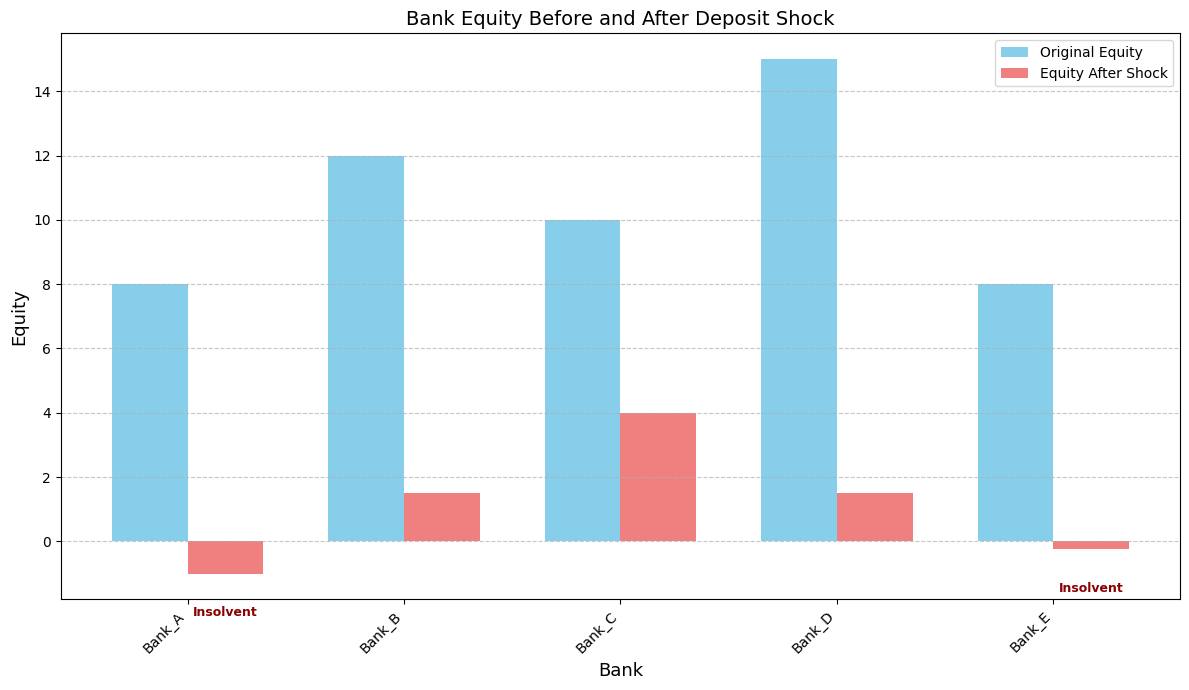

In [25]:
fig, ax = plt.subplots(figsize=(12, 7))

bank_fragility_current_order = bank_fragility_shock.copy()

x = np.arange(len(bank_fragility_current_order['Bank']))
width = 0.35

bars1 = ax.bar(x - width/2, bank_fragility_current_order['Equity'], width, label='Original Equity', color='skyblue')
bars2 = ax.bar(x + width/2, bank_fragility_current_order['Equity_shock'], width, label='Equity After Shock', color='lightcoral')

for i, (equity_shock_val, solvency_status) in enumerate(zip(bank_fragility_current_order['Equity_shock'], bank_fragility_current_order['Solvency_Status'])):
    if solvency_status == 'Insolvent':
        ax.text(x[i] + width/2, equity_shock_val - 1, 'Insolvent', ha='center', va='bottom' if equity_shock_val >= 0 else 'top', color='darkred', weight='bold', fontsize=9)

ax.set_xlabel('Bank', fontsize=13)
ax.set_ylabel('Equity', fontsize=13)
ax.set_title('Bank Equity Before and After Deposit Shock', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(bank_fragility_current_order['Bank'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Step 7 - Interpretation

Bank A and E were the two banks that became insolvent under the deposit shock. Bank A failed the most severely, with equity falling to -\$1.00 from its original position at \$8, a complete wipeout of driven by the combination of the lowest equity ratio (8%) and a large ininsured deposit base of $60. Bank E followed with equity falling to -\$0.25, the closest call in the system, sitting barely below the insolvency threshold.

The equity ratio was the decisive variable, Bank C and Bank Dboth held significantly more assests than Bank A and Bank E, yet survived because their equity buffers were proportionally stronger. Bank B is the most instructive case, it has the largest uninsured deposit based \$70, yet remained solvent with equity of \$1.50 because its higher capitalisation absorbed the withdrawal shock. This confirms that size alone does not determine survival, the ratio of equity to assets is the critical protective factor.

Size was largely neutral, what mattered was capitalisation relative to the uninsured deposit base. Bank D is the largest insitituion with \$150 in assets, yet survived comfortably with post-shock equity of \$1.50. Meanwhile, Bank A, the second smallest, failed entirely. This suggests that a large balance sheet provides no inherent protection if the equity ratio is thin and the uninsured deposit exposure is high relative to capital.

# Part 4B - Interactive Bank Stress Test

In [26]:
import ipywidgets as widgets
from IPython.display import display

# --- Core Calculation ---
def compute_stress_all(bond_decline, deposit_withdrawal):
    results = []
    for _, bank in bank_fragility.iterrows():
        asset_loss      = bank['Bond_Portfolio'] * bond_decline
        deposit_outflow = bank['Uninsured_Deposits'] * deposit_withdrawal
        updated_assets  = bank['Assets'] - asset_loss - deposit_outflow
        updated_equity  = updated_assets - bank['Liabilities']
        solvent         = updated_equity > 0
        results.append({
            'bank':           bank['Bank'],
            'updated_assets': updated_assets,
            'updated_equity': updated_equity,
            'solvent':        solvent
        })
    return results

# --- Sliders ---
slider_style  = {'description_width': '200px'}
slider_layout = widgets.Layout(width='600px')

bond_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=0.30, step=0.01,
    description='Bond Portfolio Decline (%):',
    style=slider_style, layout=slider_layout
)

deposit_slider = widgets.FloatSlider(
    value=0.0, min=0.0, max=0.50, step=0.01,
    description='Deposit Withdrawal (%):',
    style=slider_style, layout=slider_layout
)

output = widgets.Output(layout=widgets.Layout(margin='20px 0px'))

def update(change):
    output.clear_output()
    results = compute_stress_all(bond_slider.value, deposit_slider.value)

    rows = ""
    for r in results:
        color  = '#27ae60' if r['solvent'] else '#c0392b'
        label  = '✅ Solvent' if r['solvent'] else '❌ Insolvent'
        rows += f"""
        <tr>
            <td style="padding:10px;"><b>{r['bank']}</b></td>
            <td style="padding:10px;">${r['updated_assets']:,.2f}</td>
            <td style="padding:10px;">${r['updated_equity']:,.2f}</td>
            <td style="padding:10px; color:{color}; font-weight:bold;">{label}</td>
        </tr>"""

    solvent_count   = sum(1 for r in results if r['solvent'])
    insolvent_count = len(results) - solvent_count
    system_color    = '#27ae60' if insolvent_count == 0 else '#c0392b'

    with output:
        display(widgets.HTML(f"""
        <div style="font-size:16px; font-family:monospace; padding:20px;
                    background:#f7f7f7; border-radius:10px; width:620px;">
            <div style="font-size:22px; font-weight:bold; margin-bottom:15px;">📥 Stress Inputs</div>
            <div style="margin:8px 0;">Bond Portfolio Decline: <b>{bond_slider.value:.2%}</b></div>
            <div style="margin:8px 0;">Deposit Withdrawal: <b>{deposit_slider.value:.2%}</b></div>
            <hr style="margin:15px 0;">
            <div style="font-size:22px; font-weight:bold; margin-bottom:15px;">📤 Stress Test Results</div>
            <table style="width:100%; border-collapse:collapse; text-align:left;">
                <thead>
                    <tr style="background:#ddd;">
                        <th style="padding:10px;">Bank</th>
                        <th style="padding:10px;">Updated Assets</th>
                        <th style="padding:10px;">Updated Equity</th>
                        <th style="padding:10px;">Solvency</th>
                    </tr>
                </thead>
                <tbody>{rows}</tbody>
            </table>
            <hr style="margin:15px 0;">
            <div style="font-size:22px; font-weight:bold; color:{system_color};">
                System: {solvent_count} Solvent / {insolvent_count} Insolvent
            </div>
        </div>
        """))

bond_slider.observe(update,    names='value')
deposit_slider.observe(update, names='value')

update(None)

display(widgets.VBox([
    widgets.HTML("<h2 style='font-size:26px;'>🏦 Interactive Bank Stress Test — All Banks</h2>"),
    bond_slider,
    deposit_slider,
    output
], layout=widgets.Layout(padding='20px')))

Combination 1:

    Bond Portfolio Decline (%): 30%
    Deposit Withdrawal (%): 30%


Combination 2:

    Bond Portfolio Decline (%): 10%
    Deposit Withdrawal (%): 30%



Combination 3:

    Bond Portfolio Decline (%): 20%
    Deposit Withdrawal (%): 4%


In Scenario 1, a severe combined shock of 30% bond portfolio decline and 30% deposit withdrawal pushed all five banks into insolvency, with no survivors. This scenario demonstrated that simultaneous liquidity and capital shocks are devastating - even Bank C, the strongest institution, fell to -\$9.50, and Bank D, the largest, collapsed to -\$33.00, confirming that neither capitalisation nor size provides protection under extreme stress. In Scenario 2, the bond decline was reduced to 10% while the deposit withdrawal remained at 30%, yet all five banks still became insolvent. This was a notable finding, as it revealed that under the corrected solvency definition - where assets must exceed liabilities - a 30% deposit withdrawal alone is sufficient to render the entire system insolvent, even without severe bond losses. This highlights how exposed these banks are to deposit flight. In Scenario 3, a 20% bond decline combined with a 4% deposit withdrawal produced mixed outcomes - four banks became insolvent while Bank C was the sole survivor with equity of \$3.40. This scenario was the most instructive, as it identified Bank A as the most structurally fragile institution, falling first with equity of -\$2.40 despite receiving the smallest relative shock, a direct consequence of its low equity ratio of 8%.

## Interpretation Questions

Bond losses and deposit withdrawals are both dangerous, but operate through different channels. Scenario 2 demonstrated that a 10% bond decline combined with a 30% deposit withdrawal was sufficient to render all five banks insolvent, showing that large deposit outflows are a serious threat when solvency is measured as assets exceeding liabilities. Bond losses directly destroy equity by reducing assets without any corresponding reduction in liabilities, making them an immediate capital threat. Deposit withdrawals produce the same insolvency outcome through asset drainage, confirming that both shocks are dangerous in combination.

Bank A's tipping point was most precisely identified in Scenario 3 - at a 20% bond decline and 4% deposit withdrawal, its equity fell to -$2.40, confirming it as the most structurally fragile institution in the system. Bank C, by contrast, survived all three scenarios, suggesting its solvency threshold lies well above the shock levels tested.

Failure appears sudden rather than gradual. Across all three scenarios, banks either remained solvent or collapsed past zero abruptly - there is no visible middle ground of gradual deterioration. This is consistent with real banking crises, where institutions appear stable until a tipping point is reached and confidence evaporates rapidly.

# Part 5 - Your Custom Shock

In [27]:
bank_fragility

,Bank,Assets,Liabilities,Bond_Portfolio,Uninsured_Deposits,Equity,Equity_Ratio
0,Bank_A,100,92,40,60,8,0.080000
1,Bank_B,120,108,50,70,12,0.100000
2,Bank_C,80,70,25,40,10,0.125000
3,Bank_D,150,135,70,90,15,0.100000
4,Bank_E,90,82,30,55,8,0.088889


For my custom shock, I have chosen a tiered deposit withdrawal approach,
where weaker banks face a larger withdrawal rate than stronger ones.
This reflects how real banking panics happen - depositors and markets
target the most fragile institutions first. Withdrawal rates are assigned
based on each bank's equity ratio, with the weakest bank (Bank A) facing
a 40% withdrawal and the strongest (Bank C) facing only 20%. This is more
realistic than a flat shock as it captures the dynamic where perceived
fragility accelerates deposit withdrawals.

In [28]:
bank_fragility_custom_shock = bank_fragility.copy()

# Tiered deposit withdrawal shock based on equity ratio
shock_map = {
    'Bank_A': 0.40,   # weakest  — 40% withdrawal
    'Bank_E': 0.35,   # weak     — 35% withdrawal
    'Bank_D': 0.30,   # moderate — 30% withdrawal
    'Bank_B': 0.25,   # moderate — 25% withdrawal
    'Bank_C': 0.20,   # strongest — 20% withdrawal
}

bank_fragility_custom_shock['Withdrawal_Rate']         = bank_fragility_custom_shock['Bank'].map(shock_map)
deposit_reduction                                       = (bank_fragility_custom_shock['Uninsured_Deposits']
                                                          * bank_fragility_custom_shock['Withdrawal_Rate'])
bank_fragility_custom_shock['Uninsured_Deposits_shock'] = bank_fragility_custom_shock['Uninsured_Deposits'] - deposit_reduction
bank_fragility_custom_shock['Assets_shock']             = bank_fragility_custom_shock['Assets'] - deposit_reduction

bank_fragility_custom_shock

,Bank,Assets,Liabilities,Bond_Portfolio,Uninsured_Deposits,Equity,Equity_Ratio,Withdrawal_Rate,Uninsured_Deposits_shock,Assets_shock
0,Bank_A,100,92,40,60,8,0.080000,0.40,36.00,76.00
1,Bank_B,120,108,50,70,12,0.100000,0.25,52.50,102.50
2,Bank_C,80,70,25,40,10,0.125000,0.20,32.00,72.00
3,Bank_D,150,135,70,90,15,0.100000,0.30,63.00,123.00
4,Bank_E,90,82,30,55,8,0.088889,0.35,35.75,70.75


In [29]:
bank_fragility_custom_shock['Equity_shock'] = bank_fragility_custom_shock['Assets_shock'] - bank_fragility_custom_shock['Liabilities']
bank_fragility_custom_shock['Solvency_Status'] = np.where(bank_fragility_custom_shock['Equity_shock'] > 0, 'Solvent', 'Insolvent')

bank_fragility_custom_shock

,Bank,Assets,Liabilities,Bond_Portfolio,Uninsured_Deposits,Equity,Equity_Ratio,Withdrawal_Rate,Uninsured_Deposits_shock,Assets_shock,Equity_shock,Solvency_Status
0,Bank_A,100,92,40,60,8,0.080000,0.40,36.00,76.00,-16.00,Insolvent
1,Bank_B,120,108,50,70,12,0.100000,0.25,52.50,102.50,-5.50,Insolvent
2,Bank_C,80,70,25,40,10,0.125000,0.20,32.00,72.00,2.00,Solvent
3,Bank_D,150,135,70,90,15,0.100000,0.30,63.00,123.00,-12.00,Insolvent
4,Bank_E,90,82,30,55,8,0.088889,0.35,35.75,70.75,-11.25,Insolvent


Yes, the outcomes changed dramatically compared to the flat shock scenarios. Under the tiered withdrawal shock, four out of five banks became insolvent, with only Bank C surviving at a modest equity of \$2.00. The most striking result is Bank A, which suffered the largest equity destruction at -\$16.00 despite having the smallest asset base - a direct consequence of receiving the harshest withdrawal rate of 40% due to its weak equity ratio of 8.00%. This tiered approach produced a far more severe outcome than any flat shock tested previously.

The system was deeply fragile. A deposit-only shock - with no bond losses applied whatsoever - was sufficient to make 80% of the banking system insolvent. The fact that equity was destroyed purely through asset drainage, without any direct capital destruction from bond losses, underscores how thin the equity buffers were across the system. Bank C's survival with just \$2.00 in remaining equity cannot be described as stability - it is survival by the narrowest possible margin.

Yes, especially for Bank E. Despite receiving a 35% withdrawal rate - only 5 percentage points higher than Bank B's 25% - its equity fell to -\$11.25 compared to Bank B's -\$5.50. This disproportionate outcome reflects how a moderately larger shock interacts with a weaker equity base to produce a nonlinearly worse result, confirming that the system's fragility is highly sensitive to even small differences in shock intensity.

# Final Section - Reflection

The banking system appears more fragile based on the evidence gathered throughout this analysis. The sovereign system showed meaningful but controlled fragility - under post-shock conditions, the joint probability of at least one default reached 69.82% across eight countries, with individual default probabilites ranging from 11.01% to 16.95%. However, this risk remained probabilistic and distributed. Even the most distressed sovereign, Argentina, retained an 83.05% chance of surviving within the year, meaning no single country faced certain default. The banking system, by contrast, demonstrated more immediate and structural fragility. Under the tiered deposit withdrawal shock - with no bond losses applied at all - four out of five banks became insolvent outright, not probabilistically. Bank A's equity collapsed to -\$16.00 from a starting position of $8.00, and the failure was deterministic rather than probabilistic. The critical distinction between the two systems is how fragility is expressed - in the sovereign system it manifests as an elevated probability of default, leaving room for survival even under stress. In the banking system, fragility manifests as mechanical capital destruction, where a credible withdrawal shock targeting the weakest institutions is sufficient to trigger outright insolvency with certainty. This makes the banking system structurally more dangerous, as collapse does not require an unlikely event to occur - it requires only a moderate and realistic stress scenario applied unevenly across an undercapitalised system.